In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from sklearn.linear_model import Ridge
np.random.seed(42)

Simulating SIRS model with waning immunity for true second waves...


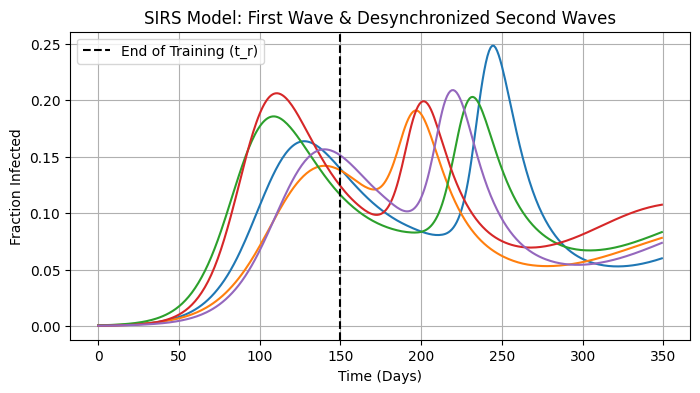

Cell 2 Updated: SIRS Second-wave data generated!


In [2]:
def sirs_deriv(t, y, beta_base, gamma, xi, surge_time, surge_amp):
    S, I, R = y
    beta_t = beta_base * (1 + surge_amp * np.exp(-((t - surge_time)**2) / 200.0))
    dSdt = -beta_t * S * I + xi * R
    dIdt = beta_t * S * I - gamma * I
    dRdt = gamma * I - xi * R
    return [dSdt, dIdt, dRdt]

N_patches = 100
M_train = 95
N_target = N_patches - M_train

t_max = 350
dt = 1.0
time_steps = np.arange(0, t_max, dt)
K = len(time_steps)

gamma = 1/14.0
xi = 1/60.0           # Immunity lasts about 60 days on average

all_I_data = np.zeros((N_patches, K))

print("Simulating SIRS model with waning immunity for true second waves...")

for j in range(N_patches):
    beta_base = np.random.uniform(0.12, 0.16)
    surge_time = np.random.uniform(180, 240) # Second wave hits between day 180 and 240
    surge_amp = np.random.uniform(1.0, 1.8)
    I0 = np.random.uniform(1e-4, 5e-4)

    res = solve_ivp(sirs_deriv, [0, t_max], [1.0 - I0, I0, 0.0],
                    t_eval=time_steps, args=(beta_base, gamma, xi, surge_time, surge_amp))
    all_I_data[j, :] = res.y[1]

input_data = all_I_data[:M_train, :]
target_data = all_I_data[M_train:, :]
split_idx = 150
t_train = time_steps[:split_idx]
t_test = time_steps[split_idx:]

plt.figure(figsize=(8, 4))
for i in range(5):
    plt.plot(time_steps, input_data[i, :], linewidth=1.5)
plt.axvline(x=time_steps[split_idx], color='k', linestyle='--', label='End of Training (t_r)')
plt.title("SIRS Model: First Wave & Desynchronized Second Waves")
plt.xlabel("Time (Days)")
plt.ylabel("Fraction Infected")
plt.legend()
plt.grid(True)
plt.show()

print("Cell 2 Updated: SIRS Second-wave data generated!")

In [3]:
N_res = 1000   # Size of the reservoir
alpha = 0.5    # Leakage rate (how much 'memory' it retains)

W_in = np.random.uniform(-1, 1, (N_res, M_train))
W_res = np.random.uniform(-1, 1, (N_res, N_res))

eigenvalues = np.linalg.eigvals(W_res)
spectral_radius = np.max(np.abs(eigenvalues))
W_res = (W_res / spectral_radius) * 0.9
r_t = np.zeros((N_res, 1))
X_train = np.zeros((N_res + M_train, split_idx))

for t in range(split_idx):
    # Get the input data for all 95 patches at time t
    s_t = input_data[:, t].reshape(-1, 1)

    # Equation 1: The Reservoir Update Rule
    r_t = (1 - alpha) * r_t + alpha * np.tanh(np.dot(W_res, r_t) + np.dot(W_in, s_t))

    # Stack input s(t) and reservoir state r(t), then flatten to store in X
    X_train[:, t] = np.vstack((s_t, r_t)).flatten()

Y_train = target_data[:, :split_idx]

Output weights shape: (5, 1095)


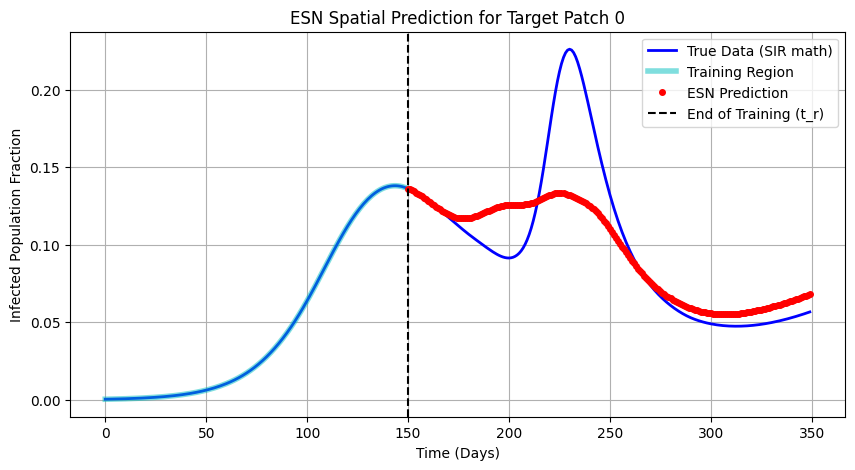

In [4]:
ridge = Ridge(alpha=1e-4, fit_intercept=False)
ridge.fit(X_train.T, Y_train.T)
W_out = ridge.coef_  # Shape should be (5, N_res + M_train)
print(f"Output weights shape: {W_out.shape}")
predictions = np.zeros((N_target, len(t_test)))

for t_idx, t in enumerate(range(split_idx, K)):
    s_t = input_data[:, t].reshape(-1, 1)
    r_t = (1 - alpha) * r_t + alpha * np.tanh(np.dot(W_res, r_t) + np.dot(W_in, s_t))
    x_test = np.vstack((s_t, r_t)).flatten()
    predictions[:, t_idx] = np.dot(W_out, x_test)
patch_to_plot = 0

plt.figure(figsize=(10, 5))
plt.plot(time_steps, target_data[patch_to_plot, :], 'b-', linewidth=2, label='True Data (SIR math)')
plt.plot(t_train, target_data[patch_to_plot, :split_idx], 'c-', alpha=0.5, linewidth=4, label='Training Region')
plt.plot(t_test, predictions[patch_to_plot, :], 'ro', markersize=4, label='ESN Prediction')

plt.axvline(x=time_steps[split_idx], color='k', linestyle='--', label='End of Training (t_r)')
plt.title(f'ESN Spatial Prediction for Target Patch {patch_to_plot}')
plt.xlabel('Time (Days)')
plt.ylabel('Infected Population Fraction')
plt.legend()
plt.grid(True)
plt.show()

Training the time-shifted Readout Layer...


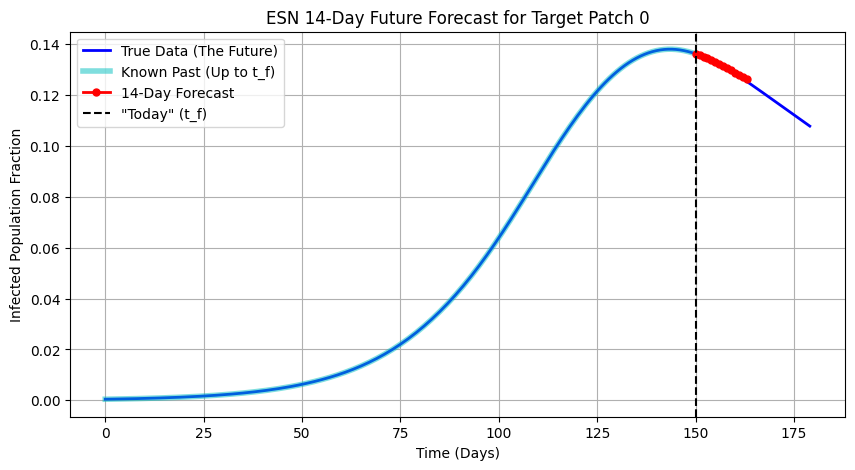

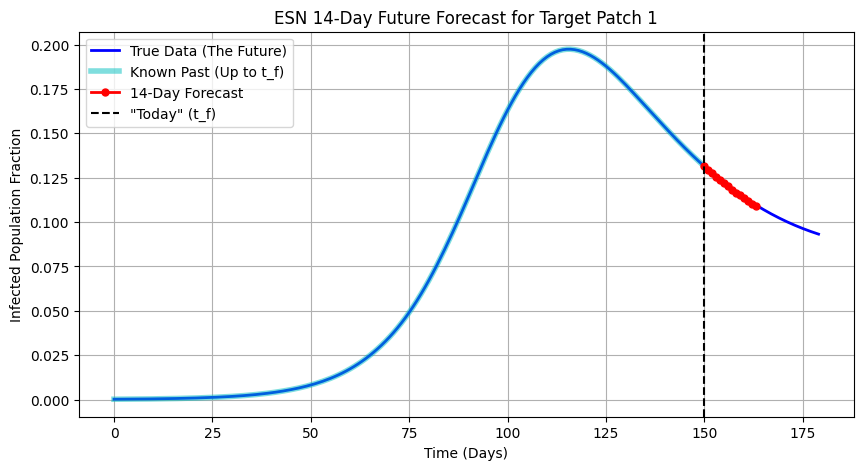

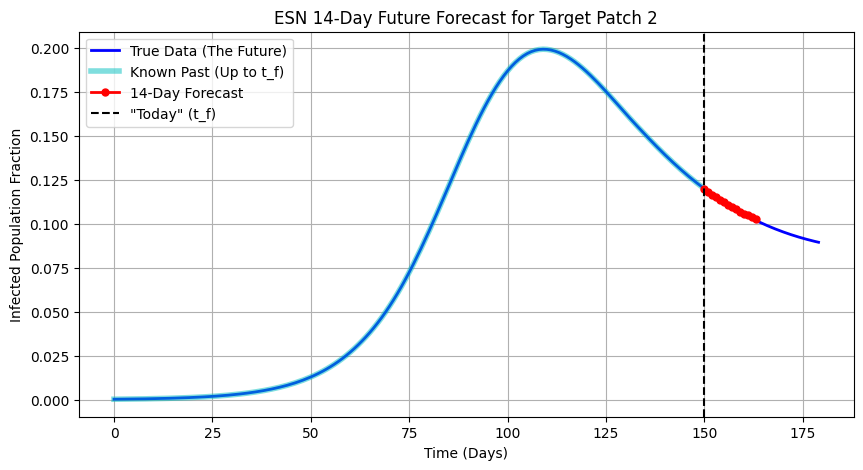

Cell 5: Future Forecasting complete!


In [5]:
tau = 14          # Predict 14 days into the future
t_f = 150         # "Today" - the last day we have data for

r_t_forecast = np.zeros((N_res, 1))
X_tf = np.zeros((N_res + M_train, t_f))

for t in range(t_f):
    s_t = input_data[:, t].reshape(-1, 1)
    r_t_forecast = (1 - alpha) * r_t_forecast + alpha * np.tanh(np.dot(W_res, r_t_forecast) + np.dot(W_in, s_t))
    X_tf[:, t] = np.vstack((s_t, r_t_forecast)).flatten()
X_train_shifted = X_tf[:, :t_f - tau]     # Reservoir states from Day 0 to Day 136
Y_train_shifted = target_data[:, tau:t_f] # Target data from Day 14 to Day 150
print("Training the time-shifted Readout Layer...")
ridge_forecast = Ridge(alpha=1e-4, fit_intercept=False)
ridge_forecast.fit(X_train_shifted.T, Y_train_shifted.T)
W_out_forecast = ridge_forecast.coef_
X_recent = X_tf[:, t_f - tau : t_f]
future_predictions = np.dot(W_out_forecast, X_recent)
for patch_to_plot in range(3):
    future_time = time_steps[t_f : t_f + tau]

    plt.figure(figsize=(10, 5))
    plt.plot(time_steps[:180], target_data[patch_to_plot, :180], 'b-', linewidth=2, label='True Data (The Future)')
    plt.plot(time_steps[:t_f], target_data[patch_to_plot, :t_f], 'c-', alpha=0.5, linewidth=4, label='Known Past (Up to t_f)')
    plt.plot(future_time, future_predictions[patch_to_plot, :], 'r-o', markersize=5, linewidth=2, label=f'{tau}-Day Forecast')

    plt.axvline(x=t_f, color='k', linestyle='--', label='"Today" (t_f)')
    plt.title(f'ESN {tau}-Day Future Forecast for Target Patch {patch_to_plot}')
    plt.xlabel('Time (Days)')
    plt.ylabel('Infected Population Fraction')
    plt.legend()
    plt.grid(True)
    plt.show()

print("Cell 5: Future Forecasting complete!")

In [6]:
import pandas as pd
from scipy.signal import savgol_filter
url = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv"
df = pd.read_csv(url)
df_country = df.drop(columns=['Province/State', 'Lat', 'Long']).groupby('Country/Region').sum()
df_daily = df_country.diff(axis=1).fillna(0)
df_daily[df_daily < 0] = 0 # Clean any negative reporting anomalies
total_cases = df_country.iloc[:, -1]
df_filtered = df_daily[total_cases >= 10000]
raw_real_data = df_filtered.values
raw_real_data = raw_real_data[:, :280]
window_length = 21
poly_order = 3
smoothed_data = savgol_filter(raw_real_data, window_length, poly_order, axis=1)
smoothed_data[smoothed_data < 0] = 0 # Ensure no negative cases after smoothing
N_real_patches = smoothed_data.shape[0]
M_real_train = int(N_real_patches * 0.95)
N_real_target = N_real_patches - M_real_train
np.random.seed(42)
indices = np.random.permutation(N_real_patches)
shuffled_data = smoothed_data[indices]
country_names = df_filtered.index[indices]

real_input_data = shuffled_data[:M_real_train, :]
real_target_data = shuffled_data[M_real_train:, :]
target_countries = country_names[M_real_train:]

print(f"Total Countries: {N_real_patches}")
print(f"Input Countries (M): {M_real_train}")
print(f"Target Countries (N-M): {N_real_target}")
print(f"Target Country Names: {list(target_countries)}")

Total Countries: 180
Input Countries (M): 171
Target Countries (N-M): 9
Target Country Names: ['Indonesia', 'Norway', 'Zimbabwe', 'Bosnia and Herzegovina', 'Hungary', 'Mexico', 'Belarus', 'Lesotho', 'Malta']


Total days: 280. Training on 273, predicting 7.


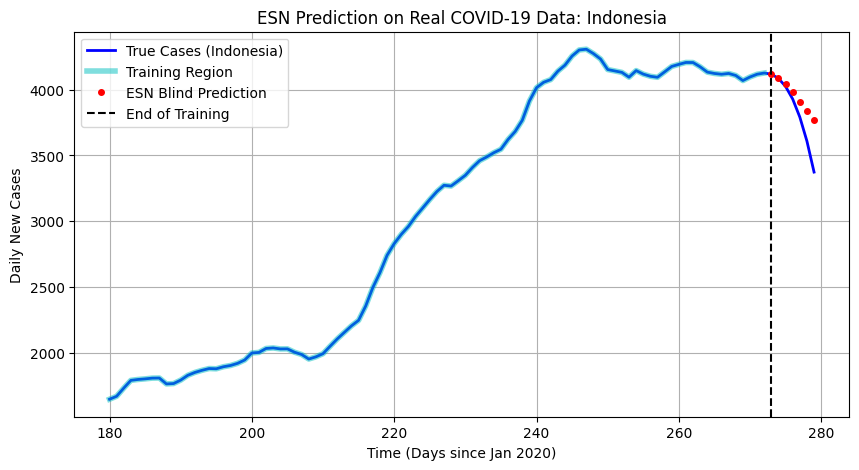

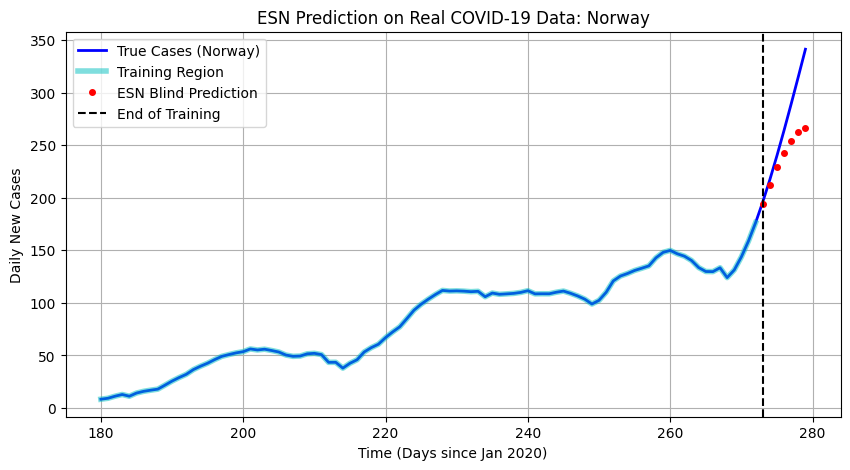

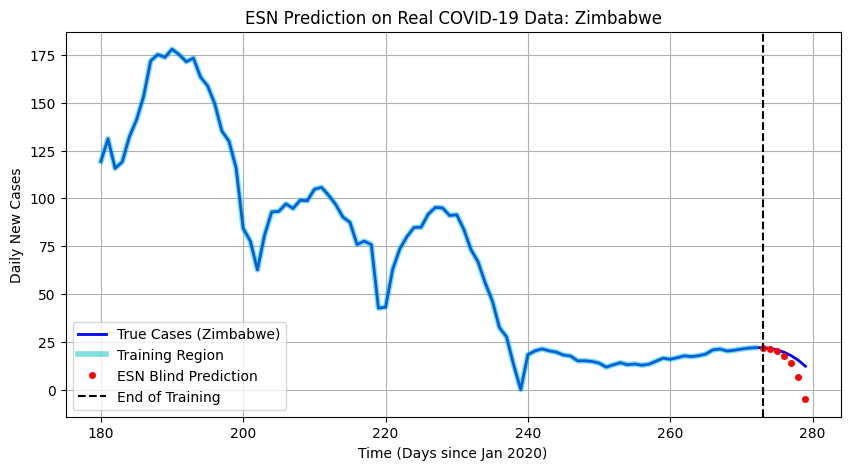

In [7]:
from sklearn.preprocessing import MinMaxScaler
total_days = real_input_data.shape[1]
predict_days = 7 # Forecast the last 7 days blind
split_idx_real = total_days - predict_days
t_train_real = np.arange(0, split_idx_real)
t_test_real = np.arange(split_idx_real, total_days)
print(f"Total days: {total_days}. Training on {split_idx_real}, predicting {predict_days}.")
scaler_in = MinMaxScaler()
scaler_out = MinMaxScaler()
input_scaled = scaler_in.fit_transform(real_input_data.T).T
target_scaled = scaler_out.fit_transform(real_target_data.T).T
N_res_real = 1000
alpha_real = 0.5

W_in_real = np.random.uniform(-1, 1, (N_res_real, M_real_train))
W_res_real = np.random.uniform(-1, 1, (N_res_real, N_res_real))
spectral_radius_real = np.max(np.abs(np.linalg.eigvals(W_res_real)))
W_res_real = (W_res_real / spectral_radius_real) * 0.9
r_t_real = np.zeros((N_res_real, 1))
X_train_real = np.zeros((N_res_real + M_real_train, split_idx_real))

for t in range(split_idx_real):
    s_t = input_scaled[:, t].reshape(-1, 1) # Feed SCALED input
    r_t_real = (1 - alpha_real) * r_t_real + alpha_real * np.tanh(np.dot(W_res_real, r_t_real) + np.dot(W_in_real, s_t))
    X_train_real[:, t] = np.vstack((s_t, r_t_real)).flatten()
Y_train_real = target_scaled[:, :split_idx_real] # Target SCALED output
ridge_real = Ridge(alpha=1e-2, fit_intercept=False)
ridge_real.fit(X_train_real.T, Y_train_real.T)
W_out_real = ridge_real.coef_
predictions_scaled = np.zeros((N_real_target, predict_days))

for t_idx, t in enumerate(range(split_idx_real, total_days)):
    s_t = input_scaled[:, t].reshape(-1, 1) # Feed SCALED input
    r_t_real = (1 - alpha_real) * r_t_real + alpha_real * np.tanh(np.dot(W_res_real, r_t_real) + np.dot(W_in_real, s_t))
    x_test = np.vstack((s_t, r_t_real)).flatten()
    predictions_scaled[:, t_idx] = np.dot(W_out_real, x_test)
predictions_real = scaler_out.inverse_transform(predictions_scaled.T).T
for target_idx in range(3):
    country_name = target_countries[target_idx]
    plt.figure(figsize=(10, 5))
    view_start = total_days - 100
    view_time = np.arange(view_start, total_days)
    plt.plot(view_time, real_target_data[target_idx, view_start:], 'b-', linewidth=2, label=f'True Cases ({country_name})')
    plt.plot(t_train_real[t_train_real >= view_start], real_target_data[target_idx, view_start:split_idx_real], 'c-', alpha=0.5, linewidth=4, label='Training Region')
    plt.plot(t_test_real, predictions_real[target_idx, :], 'ro', markersize=4, label='ESN Blind Prediction')
    plt.axvline(x=split_idx_real, color='k', linestyle='--', label='End of Training')
    plt.title(f'ESN Prediction on Real COVID-19 Data: {country_name}')
    plt.xlabel('Time (Days since Jan 2020)')
    plt.ylabel('Daily New Cases')
    plt.legend()
    plt.grid(True)
    plt.show()